In [3]:
# %load examples/fidelity-gradient-tti.py
#!/usr/bin/env python

# Computation takes roughly 10 minutes.

import sys
sys.path.insert(0,'..')

import numpy as np
import matplotlib.pyplot as plt

import oqupy
import oqupy.operators as op

from oqupy.tti_tempo import TTITempo
from scipy.optimize import minimize

# --- Parameters --------------------------------------------------------------

# parameters used in https://arxiv.org/abs/2303.16002

# -- time steps --
end_time = 2.5
num_steps = 50
dt = end_time / num_steps

num_steps = 200

# -- bath --
alpha =  0.126 
omega_cutoff = 3.04 
temperature = 5 * 0.1309 
pt_dkmax = 60 
pt_epsrel = 10**(-7) 

# -- initial and target state --
initial_state = op.spin_dm('x-')
target_derivative = op.spin_dm('x+').T

# -- initial parameter guess, defined over half-timesteps --
y0 = np.zeros(2*num_steps)
z0 = np.ones(2*num_steps) * (np.pi) / (num_steps*dt)
x0 = np.zeros(2*num_steps)

parameters = np.vstack((x0,y0,z0)).T
num_params = parameters.shape[1]
print(parameters.shape)

# --- Compute process tensors -------------------------------------------------

correlations = oqupy.PowerLawSD(
    alpha=alpha,
    zeta=3,
    cutoff=omega_cutoff,
    cutoff_type='gaussian',
    temperature=temperature)
bath = oqupy.Bath(0.5* op.sigma('z'), correlations)
pt_tempo_parameters = oqupy.TempoParameters(
    dt=dt,
    epsrel=pt_epsrel,
    dkmax=pt_dkmax)

pt=TTITempo(bath,start_time=0.0,parameters=pt_tempo_parameters)
process_tensor=pt.get_process_tensor()

#process_tensor = oqupy.pt_tempo_compute(
#    bath=bath,
#    start_time=0.0,
#    end_time=pt_end_time,
#    parameters=pt_tempo_parameters)

# --- Define parameterized system ----------------------------------------------

hs_dim = 2

def hamiltonian(x, y, z):
    h = np.zeros((2,2),dtype='complex128')
    for var, var_name in zip([x,y,z], ['x', 'y', 'z']):
        h += 0.5* var * op.sigma(var_name)
    return h

parametrized_system = oqupy.ParameterizedSystem(hamiltonian)

# --- Compute fidelity, dynamics, and fidelity gradient -----------------------

from oqupy.gradient import state_gradient

fidelity_dict = state_gradient(
        system=parametrized_system,
        initial_state=initial_state,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=parameters,
        num_steps=num_steps)

final_state = fidelity_dict['dynamics'].states[-1]
v_final_state = np.reshape(final_state,hs_dim**2)
v_target_derivative = np.reshape(target_derivative.T,hs_dim**2)
fidelity = v_target_derivative @ v_final_state

print(f"the fidelity is {fidelity.real}")
#print(f"the fidelity gradient is {fidelity_dict['gradient'].real}")



(400, 3)


building influence functional:  43%|████▎     | 26/60 [00:00<00:00, 244.87it/s]

building influence functional: 100%|██████████| 60/60 [00:01<00:00, 39.74it/s] 

rank  90
--> Compute forward propagation:
 18.5%   37 of  200 [#######---------------------------------] 00:00:00

100.0%  200 of  200 [########################################] 00:00:00
Elapsed time: 0.7s
--> Compute backward propagation:
100.0%  200 of  200 [########################################] 00:00:00
Elapsed time: 0.7s
--> Apply chain rule:
100.0%  200 of  200 [########################################] 00:00:14
Elapsed time: 14.4s
the fidelity is 0.9251123174366598


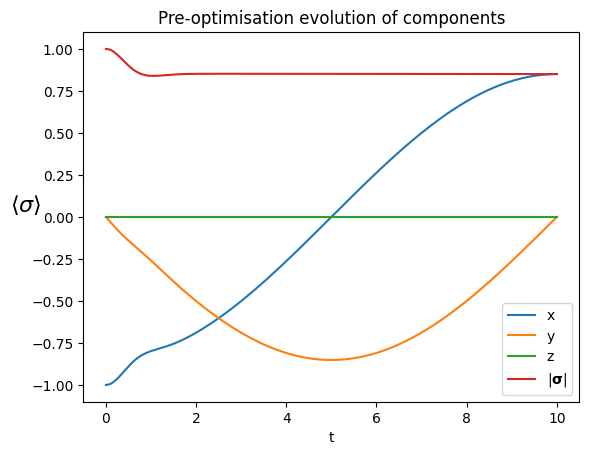

In [4]:

t, s_x = fidelity_dict['dynamics'].expectations(op.sigma("x"), real=True)
t, s_y = fidelity_dict['dynamics'].expectations(op.sigma("y"), real=True)
t, s_z = fidelity_dict['dynamics'].expectations(op.sigma("z"), real=True)
bloch_length = np.sqrt(s_x**2 +s_y**2 + s_z**2)

plt.title("Pre-optimisation evolution of components")
plt.plot(t,s_x,label='x')
plt.plot(t,s_y,label='y')
plt.plot(t,s_z,label='z')
plt.plot(t,bloch_length,label=r'$|\mathbf{\sigma}|$')

plt.ylabel(r"$\langle \sigma \rangle$",rotation=0,fontsize=16)
plt.xlabel("t")

plt.legend()


In [5]:

# ----------- Optimisation of control parameters w.r.t. infidelity ---------------

def infidandgrad(paras):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    gradient_dict = oqupy.state_gradient(
        system=parametrized_system,
        initial_state=initial_state,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=reshapedparas,
        num_steps=num_steps,
        progress_type='silent')
    
    fs=gradient_dict['final_state']
    gps=gradient_dict['gradient']
    fidelity=np.sum(fs*target_derivative.T)

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]

    # Return the minus the gradient as infidelity is being minimized 
    return 1-fidelity.real,(-1.0*gps.reshape((-1)).real).tolist()

# Set upper and lower bounds on control parameters
x_bound = [-5*np.pi,5*np.pi]
y_bound = [0,0] 
z_bound = [-np.pi,np.pi]

bounds = np.zeros((num_steps*num_params,2))

for i in range(0, num_params*num_steps,num_params):
        bounds[i] = x_bound
        bounds[i+1] = y_bound
        bounds[i+2] = z_bound

y0 = np.zeros(num_steps)
z0 = np.ones(num_steps) * (np.pi) / (dt*num_steps)
x0 = np.zeros(num_steps)

# Flatten list for input to optimizer
parameter_list=[item for pair in zip(x0, y0, z0) for item in pair]

optimization_result = minimize(
                        fun=infidandgrad,
                        x0=parameter_list,
                        method='L-BFGS-B',
                        jac=True,
                        bounds=bounds,
                        options = {'disp':True, 'gtol': 7e-05}
)

print("The maximal fidelity was found to be : ",1-optimization_result.fun)

#print("The Jacobian was found to be : ",optimization_result.jac)


The maximal fidelity was found to be :  0.9965609045167145


--> Compute forward propagation:
100.0%  200 of  200 [########################################] 00:00:00
Elapsed time: 0.8s
--> Compute backward propagation:
100.0%  200 of  200 [########################################] 00:00:00
Elapsed time: 1.0s
--> Apply chain rule:
100.0%  200 of  200 [########################################] 00:00:17
Elapsed time: 17.1s


c:\Users\preas\OQuPy\.venv\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\preas\OQuPy\.venv\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


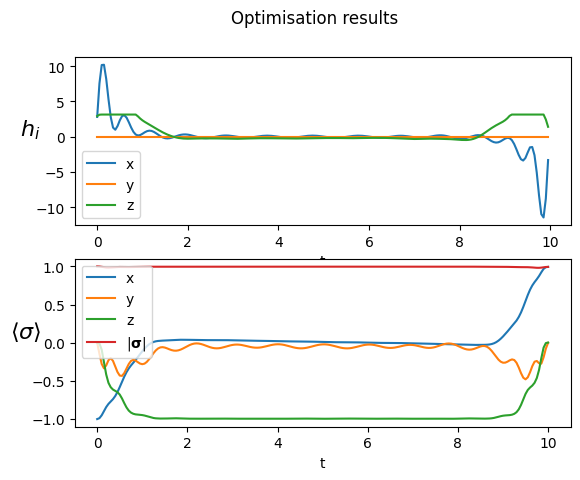

In [6]:

optimized_params = optimization_result.x
reshapedparas=np.array([i for i in (optimized_params.reshape((-1,num_params))).tolist() for j in range(2)])

# Input optimized controls into state_gradient to show dynamics of system under optimized fields
optimized_dynamics = state_gradient(
        system=parametrized_system,
        initial_state=initial_state,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=reshapedparas,
        num_steps=num_steps)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1) 
fig.suptitle("Optimisation results")

field_labels = ["x","y","z"]
for i in range(0,num_params):
     ax1.plot(t[:-1],optimization_result['x'][i::num_params],label=field_labels[i])
ax1.set_ylabel(r"$h_i$",rotation=0,fontsize=16)
ax1.set_xlabel("t")
ax1.legend()

dynamics = optimized_dynamics['dynamics']

t, bloch_x =optimized_dynamics['dynamics'].expectations(op.sigma("x"))
t, bloch_y = optimized_dynamics['dynamics'].expectations(op.sigma("y"))
t, bloch_z = optimized_dynamics['dynamics'].expectations(op.sigma("z"))

ax2.plot(t,bloch_x,label='x')
ax2.plot(t,bloch_y,label='y')
ax2.plot(t,bloch_z,label='z')
bloch_length = np.sqrt(bloch_x**2 +bloch_y**2 + bloch_z**2)
ax2.plot(t,bloch_length,label=r'$|\mathbf{\sigma}|$')
ax2.set_ylabel(r"$\langle \sigma \rangle$",rotation=0,fontsize=16)
ax2.set_xlabel("t")

plt.legend()
plt.show()

# -----------------------------------------------------------------------------

